In [ ]:
from hw3_research.modules.model import CNNModel
import torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  

import seaborn as sns

## **Загрузка данных и модели**

In [ ]:
# model
# Веса модели можно найти здесь https://drive.google.com/file/d/1_gqtjyTVpRtGToQI1t_BMZ7FGDozwIhX/view?usp=share_link
model_path = '/hw3_research/time_series_cnn.pt'

model = CNNModel(input_size=1)
model.load_state_dict(torch.load(model_path))

#device = 'mps' if torch.mps.is_available() else 'cpu'
# примечание про девайс будет ещё ниже по тексту, но да, пришлось использовать only cpu

device = 'cpu'
model.to(device)
model.eval();

#rain_data
data_train = np.loadtxt("data/FordA_TRAIN.txt")
X_train = data_train[:, np.newaxis, 1:]
y_train = data_train[:, 0].astype(int)

print(X_train.shape)  
print(y_train.shape) 

# Test data
data_test = np.loadtxt("data/FordA_TEST.txt")
X_test = data_test[:,np.newaxis, 1:]
y_test = data_test[:, 0].astype(int)

print(X_test.shape)  
print(y_test.shape) 

(3601, 1, 500)
(3601,)
(1320, 1, 500)
(1320,)


In [18]:
# dataloaders
test_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), torch.tensor((y_test + 1) / 2, dtype=torch.float32)
)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

## **Постановка задачи интерпретации**

Рассмотрим тестовый датасет. Так как модель обучена достаточно хорошо (тестовые метрики `accuracy: 0.9076`, `ROC-AUC: 0.9706`,  `F1 (macro): 0.9076`), сосредоточимся на анализе missclasification примеров. Такая постановка позволит нам не только оценить разницу сбора карт как таковых, но и посмотреть, какие участки времени наиболее сильно приводят в замешательство полученную модель. 

Прежде всего, соберем такие примеры. 


In [19]:
target_examples = []
non_target_examples = []

with torch.no_grad():
    for inputs, labels in test_dl:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits = model(inputs)                  # [batch_size, num_classes]
        probs = torch.softmax(logits, dim=1)    # вероятности
        preds = torch.argmax(probs, dim=1)      # предсказанные классы

        for i in range(inputs.size(0)): # batch
            true_label = int(labels[i].item())
            pred_label = preds[i].item()

            if pred_label != true_label:
                target_examples.append({
                    "signal": inputs[i].detach().cpu().numpy(),
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "confidence": probs[i, pred_label].item(),
                    "true_class_prob": probs[i, true_label].item(),
                })
            else:
                non_target_examples.append(inputs[i].detach().cpu().numpy())

print('Общее количество misclassification examples:', len(target_examples))

Общее количество misclassification examples: 122


Теперь будем работать с ними. 

Text(0.5, 1.0, 'Грубое приближение ошибочных и корректных классификаций')

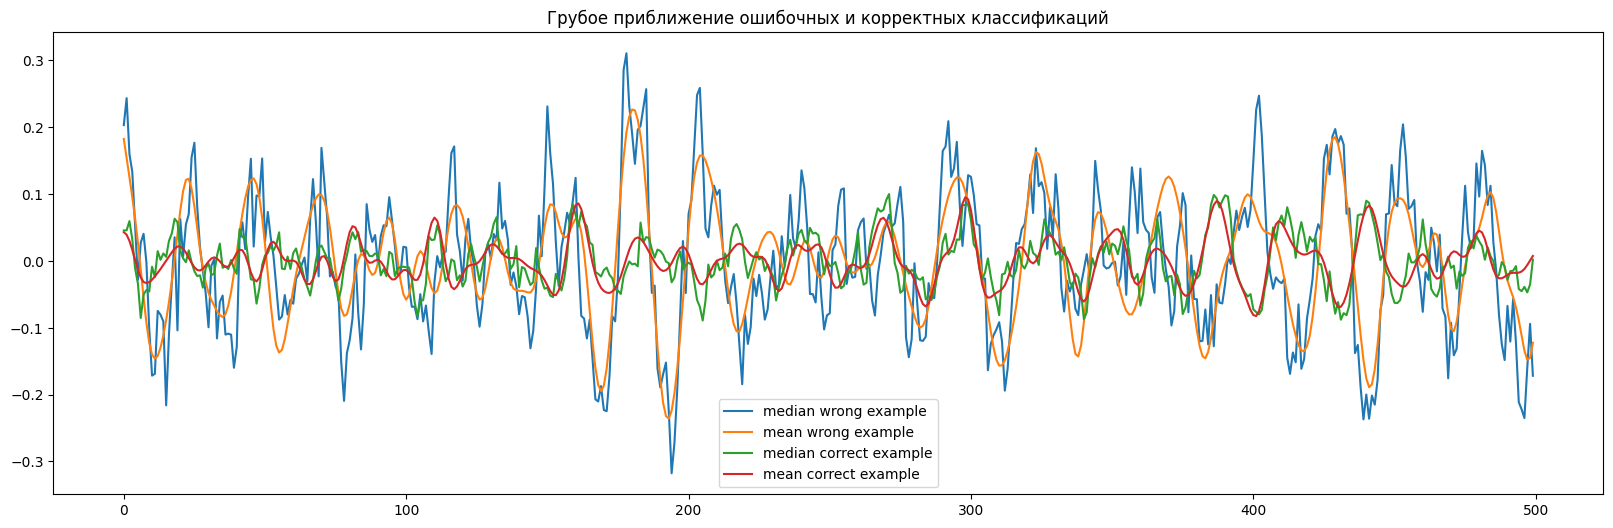

In [20]:
# сделаем матрицу, соберем preds and true
wrong_examples_matrix = np.array([target_examples[i]['signal'] for i in range(0, 122)])[:, 0, :]
wrong_examples_predictions =  np.array([target_examples[i]['pred_label'] for i in range(0, 122)])
wrong_examples_targets =  np.array([target_examples[i]['true_label'] for i in range(0, 122)])

# для некорректных соберем просто матрицу
correct_examples_matrix  = np.array(non_target_examples)[:, 0, :]

fig, ax = plt.subplots(1, 1, figsize=(20, 6))

plt.plot(np.median(wrong_examples_matrix, axis=0), label='median wrong example')
plt.plot(np.mean(wrong_examples_matrix, axis=0), label='mean wrong example')
plt.plot(np.median(correct_examples_matrix, axis=0), label='median correct example')
plt.plot(np.mean(correct_examples_matrix, axis=0), label='mean correct example')

plt.legend()
plt.title('Грубое приближение ошибочных и корректных классификаций')

Заметим, что в грубом приближении ошибочные примеры имеют более сильную амплитуду (дисперсию) во времени. Гипотеза, которая напрашивается здесь — будут ли точки, где значение разности в амплитудах наиболее сильное важными (в среднем) по ошибочной выборке или нет? Визуально выделим этим точки.  

Text(0.5, 1.0, 'Значения разности в статистиках для верно и неверно классифицированных примеров')

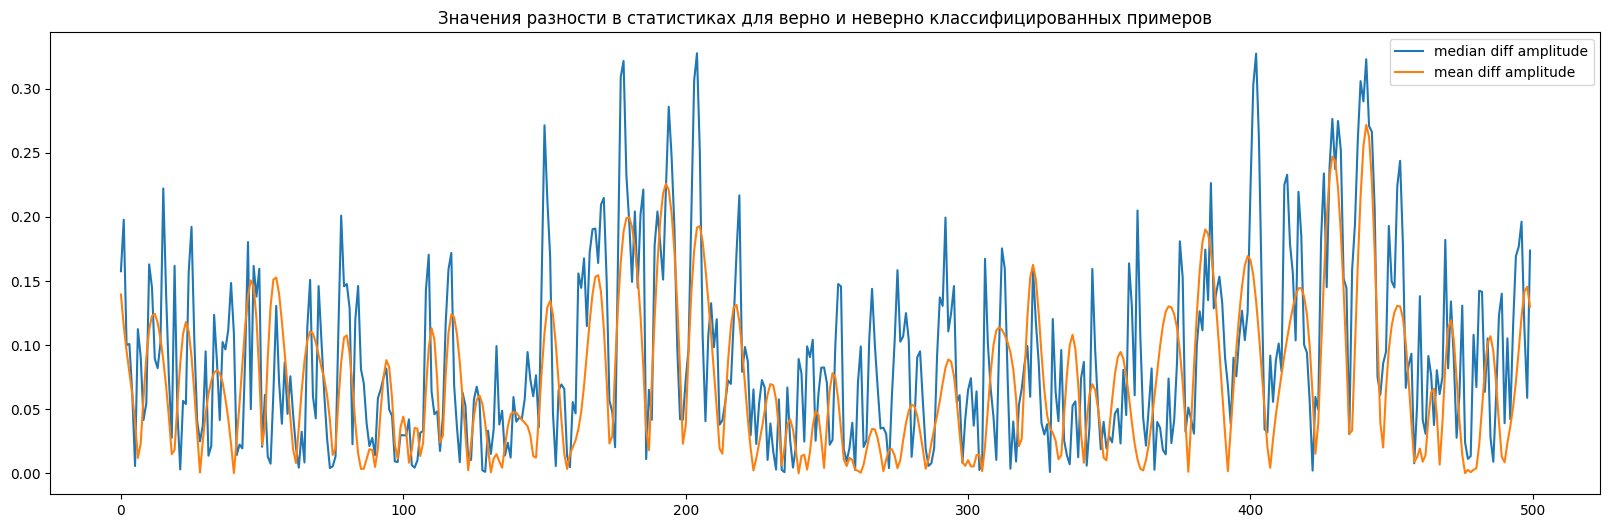

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(20, 6))

median_diff_abs = np.abs(np.median(wrong_examples_matrix, axis=0) - np.median(correct_examples_matrix, axis=0))
mean_diff_abs = np.abs(np.mean(wrong_examples_matrix, axis=0) - np.mean(correct_examples_matrix, axis=0))

# разность медиан
plt.plot(median_diff_abs, label='median diff amplitude')
plt.plot(mean_diff_abs, label='mean diff amplitude')

plt.legend()
plt.title('Значения разности в статистиках для верно и неверно классифицированных примеров')

По полученным разностям можно выдвинуть следующую гипотезу:
- наиболее значимые в wrong classification examples области от 150 до 220 (примерно) и от 390 до 470 (также примерно). 

Рассмотрим эти области с точки зрения градиетных методов интерпретации. 

## **Градиентные методы интерпретации и TSR**

Библиотека TSInterpret позволяет использовать процедуру TSR с разными картами, как применяя к ним процедуру temporal saliensy rescaling (`tsr=True`), так и ограничиваясь лишь базовой картой (`tsr=False`). Чтобы сделать бенчмаркинг наиболее информативным, мы используяем все карты с TSR и без. Кроме того, по каждой карте мы снимаем метрики `insertion` и `deletion`,  определенные далее. Таким образом, в наше постановке тестируется **9 пар карт**. 

Посмотрим на несколько примеров того, как выглдяит карта. Чтобы добавить в проект технических деталей, ты реализовали модуль gradient_methods1d, содержащий реализации базовых методов — saliency map и smooth grad. 

In [ ]:
from hw3_research.modules.gradient_methods1d import vanilla_gradients, smoothgrad

example_idx = 7
signal = wrong_examples_matrix[example_idx]      #  (500,)
item_as_tensor = torch.tensor(signal[None, None, :].astype(np.float32))  #  (1, 1, 500)

label = torch.tensor(int(wrong_examples_predictions[example_idx])) 


vanilla_saliency = vanilla_gradients(model, item_as_tensor, label)
smoth_saliency = smoothgrad(model,  item_as_tensor, label, n_samples=100, noise_level=0.3)

(<Figure size 2000x500 with 1 Axes>,
 <Axes: title={'center': 'Vanilla Saliency map'}, xlabel='Time', ylabel='Signal'>)

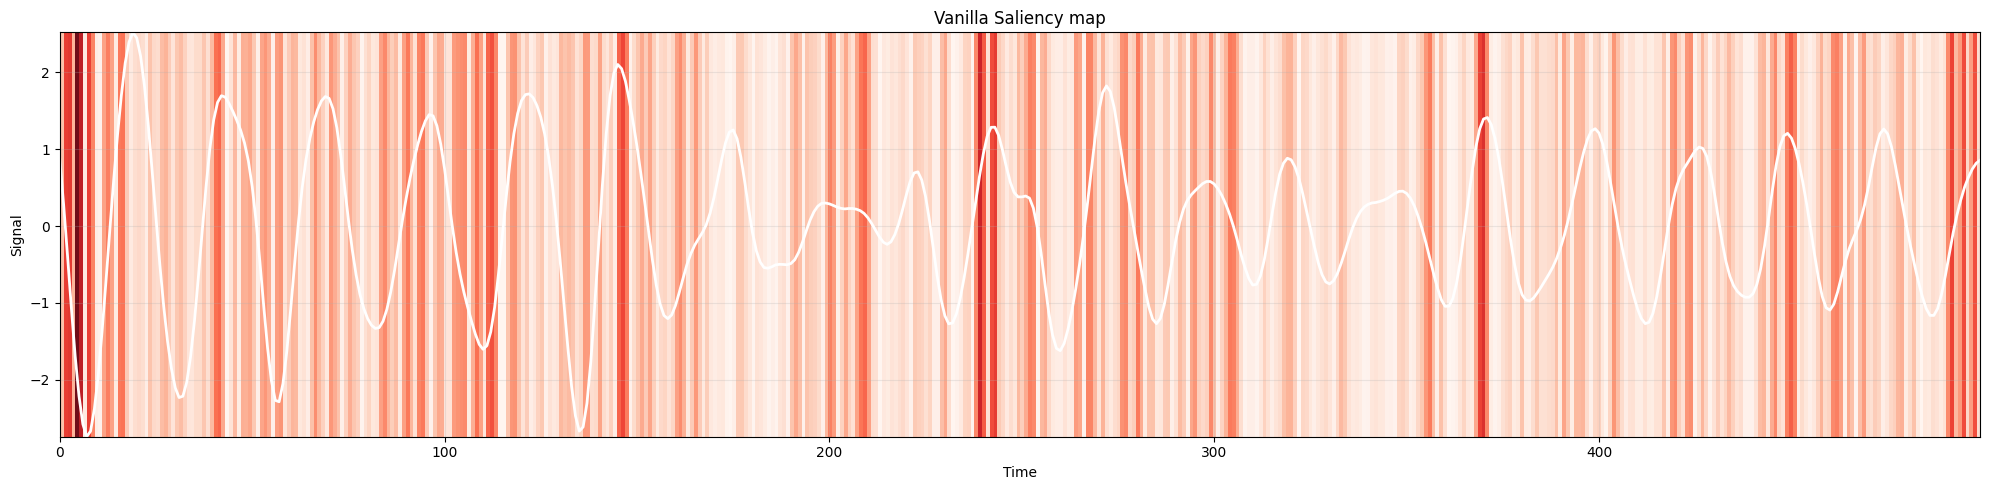

In [ ]:
from hw3_research.modules.utils import plot_signal_with_importance_background

plot_signal_with_importance_background(signal, vanilla_saliency, figsize=(20, 5), title='Vanilla Saliency map')

(<Figure size 2000x500 with 1 Axes>,
 <Axes: title={'center': 'Smooth saliency map'}, xlabel='Time', ylabel='Signal'>)

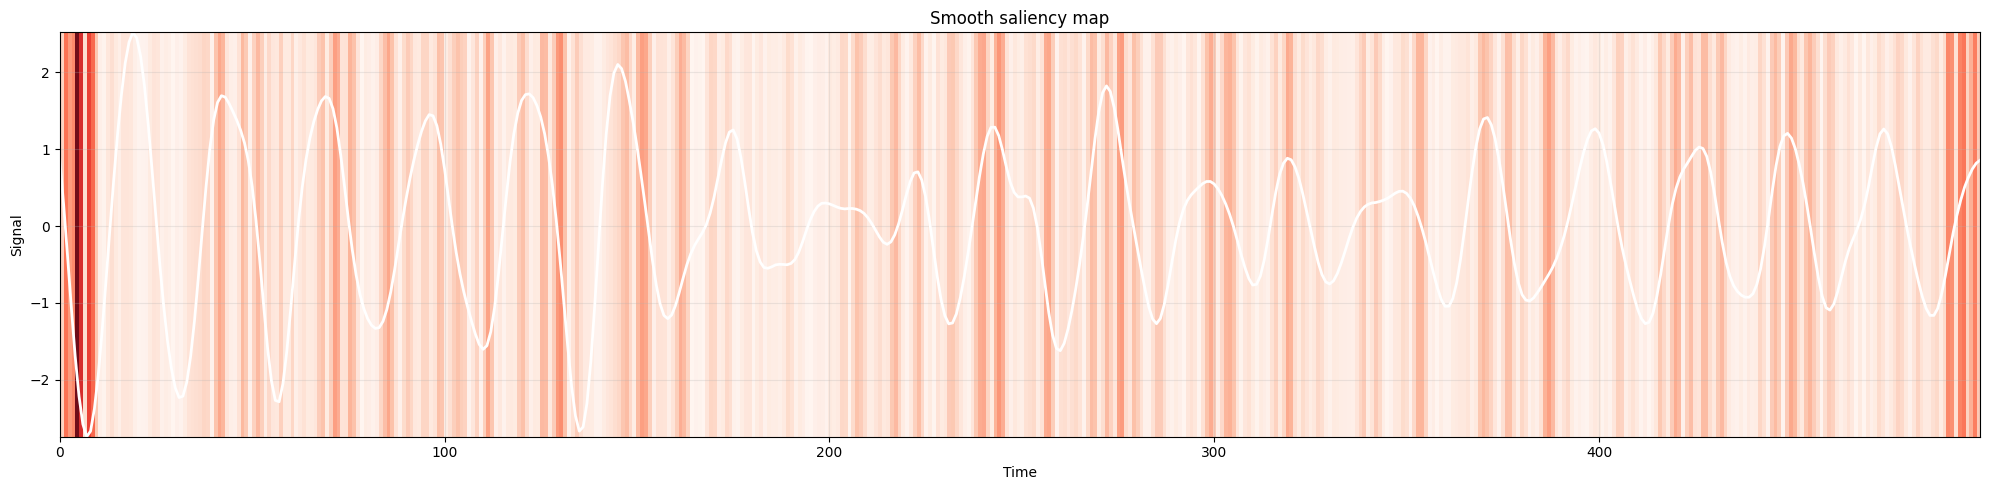

In [24]:
plot_signal_with_importance_background(signal, smoth_saliency, figsize=(20, 5), title='Smooth saliency map')

Добавление шума и проведение нескольких итерация построения карты несколько сгладило области. Общий вид карт из раза в раз будет подобен виду выше, с разными time точками, считающимися наиболее важными. 

В качестве baseline важных точек рассмотрим топ-150 точек, взятых из mean_diff_abs и median_diff_abs. То есть baseline метод важности в нашей — это просто самые сильные средние и медианные отклонения. 

In [25]:
# import numpy as np

top_k = 150

top_mean_idx = np.argsort(mean_diff_abs)[::-1][:top_k]
top_median_idx = np.argsort(median_diff_abs)[::-1][:top_k]

top_mean_set = set(top_mean_idx.tolist())
top_median_set = set(top_median_idx.tolist())

In [26]:
base_methods = ["GRAD", "GS", "DL", "DLS", "SG", "SVS", "FA", "FO"] # "IG", 

### **Оценочный прогон**

Сделаем тестовый run для одного примера на каждом методе. Градиетные методы обладают неприятым нюансом — некоторые долго ждать. Для бенчмарка положим не более часа на полный прогон (то есть в нашем сетапе +/- 30 секунд на пример). Для грубой оценки прогоним по одному примеру. 

Прогон делается на cpu, так как внутри TSInterpret подразумевается cpu-run. Конечно, там можно переписать под gpu, но в силу ограниченности времени, мы рассмотрели методы, культурно легшие на cpu. 

In [27]:
# import time 

# base_methods = ["GRAD", "IG", "GS", "DL", "DLS", "SG", "FA", "FO"]

# example_idx = 0
# signal = wrong_examples_matrix[example_idx]      #  (500,)
# item = torch.tensor(signal[None, None, :].astype(np.float32))  #  (1, 1, 500)

# label = torch.tensor(int(wrong_examples_predictions[example_idx])) 

# num_timesteps = item.shape[-1]
# num_features = 1

# rows = []

# for method in base_methods:
#     row = {"method": method}

#     print(f"{method} without TSR")
#     start = time.time()

#     int_mod = TSR(
#             model,
#             num_timesteps,
#             num_features,
#             method=method,
#             mode="feat",
#             tsr=False,
#         )

#     exp_no_tsr = int_mod.explain(
#             item,
#             labels=label,
#             TSR=False,
#             assignment=0.0
#         )

#     elapsed = time.time() - start
#     row["time_no_tsr_sec_mps"] = elapsed

#     print(f"Добежал за {elapsed} sec")
  
#     print(f"{method} with TSR")

#     start = time.time()

#     int_mod = TSR(
#             model,
#             num_timesteps,
#             num_features,
#             method=method,
#             mode="feat",
#             tsr=True,
#         )

#     exp_tsr = int_mod.explain(
#             item,
#             labels=label,
#             TSR=True,
#             assignment=0.0
#         )

#     elapsed = time.time() - start
        
#     row["time_tsr_sec_mps"] = elapsed
#     print(f"Добежал за {elapsed} sec")

#     rows.append(row)

# runtime_df = pd.DataFrame(rows)
# runtime_df

In [28]:
#runtime_df.to_csv('estimated_cpu.csv')

Теперь грубо умножим. 

In [29]:
# runtime_df['total_time_per_ex'] = runtime_df['time_no_tsr_sec'] + runtime_df['time_tsr_sec']
# runtime_df['total_runtime_min'] = runtime_df['total_time_per_ex'] * wrong_examples_matrix.shape[0] / 60

# runtime_df.sort_values(by='total_runtime_min', ascending=True)

runtime_df = pd.read_csv('/Users/sabrinasadieh/Code/time_series/hw3_research/estimated_cpu.csv', index_col=0)
runtime_df.sort_values(by='total_runtime_min', ascending=True)

,method,time_no_tsr_sec,time_tsr_sec,total_time_per_ex,total_runtime_min
0,GRAD,0.005123,0.270117,0.275240,0.559654
2,GS,0.003807,1.196918,1.200725,2.441474
5,SG,0.005078,1.276722,1.281800,2.606327
3,DL,0.002954,1.465323,1.468277,2.985497
4,DLS,0.008470,4.249861,4.258331,8.658606
1,IG,0.103268,53.301852,53.405120,108.590410
6,FA,0.183205,87.921037,88.104242,179.145292
7,FO,0.167993,91.470361,91.638354,186.331320


Для прогона на cpu возьмем методы GRAD, GS, SG, DL, DLS. Расшифровка и описание особенностей каждого см. в `theory.md`.

Код сбора статистик о оценок описан ниже. Можно перепрогнать, займет +/- 20 минут. 

In [ ]:
from hw3_research.modules.benchmark_maps import evaluate_method_on_dataset, evaluate_fixed_map_on_dataset
from tqdm.notebook import tqdm

# all_results = []

# base_methods = ["GRAD",  "GS", "DL", "DLS", "SG"]

# num_timesteps = wrong_examples_matrix.shape[1]   # 500
# num_features = 1

# for method in tqdm(base_methods):
#     print(f"{method} без TSR")
#     res_no_tsr = evaluate_method_on_dataset(
#         model=model,
#         items_matrix=wrong_examples_matrix,
#         pred_labels=wrong_examples_predictions,
#         true_labels=wrong_examples_targets,
#         method=method,
#         use_tsr=False,
#         num_timesteps=num_timesteps,
#         num_features=num_features,
#         top_mean_idx=top_mean_idx,
#         top_median_idx=top_median_idx,
#         steps=50,
#         baseline_value=0.0,
#         mode="feat",
#         window_size=5,
#         target_mode="pred",
#     )
#     all_results.append(res_no_tsr)

#     print(f"{method} с TSR")
#     res_tsr = evaluate_method_on_dataset(
#         model=model,
#         items_matrix=wrong_examples_matrix,
#         pred_labels=wrong_examples_predictions,
#         true_labels=wrong_examples_targets,
#         method=method,
#         use_tsr=True,
#         num_timesteps=num_timesteps,
#         num_features=num_features,
#         top_mean_idx=top_mean_idx,
#         top_median_idx=top_median_idx,
#         steps=50,
#         baseline_value=0.0,
#         mode="feat",
#         window_size=5,
#         target_mode="pred",
#     )
#     all_results.append(res_tsr)

In [31]:
# global_maps = {
#     "MeanDiff": mean_diff_abs,
#     "MedianDiff": median_diff_abs,
# }

# for method_name, fixed_map in tqdm(global_maps.items()):
#     print(f"{method_name} baseline")

#     res_fixed = evaluate_fixed_map_on_dataset(
#         model=model,
#         items_matrix=wrong_examples_matrix,
#         pred_labels=wrong_examples_predictions,
#         true_labels=wrong_examples_targets,
#         fixed_map=fixed_map,
#         method_name=method_name,
#         top_mean_idx=top_mean_idx,
#         top_median_idx=top_median_idx,
#         steps=50,
#         baseline_value=0.0,
#         mode="feat",
#         window_size=5,
#         target_mode="pred",
#     )

#     all_results.append(res_fixed)

In [14]:
# results_df = pd.DataFrame([{
#     "method": r["method_name"],
#     "deletion_auc_mean": r["deletion_auc_mean"],
#     "insertion_auc_mean": r["insertion_auc_mean"],
#     "mean_overlap_intersection_avg": r["mean_overlap_intersection_avg"],
#     "mean_overlap_recall_avg": r["mean_overlap_recall_avg"],
#     "mean_overlap_precision_avg": r["mean_overlap_precision_avg"],
#     "mean_overlap_jaccard_avg": r["mean_overlap_jaccard_avg"],
#     "median_overlap_intersection_avg": r["median_overlap_intersection_avg"],
#     "median_overlap_recall_avg": r["median_overlap_recall_avg"],
#     "median_overlap_precision_avg": r["median_overlap_precision_avg"],
#     "median_overlap_jaccard_avg": r["median_overlap_jaccard_avg"],
# } for r in all_results])

# results_df = results_df.sort_values(
#     by=["deletion_auc_mean", "insertion_auc_mean"],
#     ascending=[True, False]
# )

# results_df

### **Анализ метрик**


Для оценки качества explanations мы рассмотрели две группы метрик. Во-первых, рассчитывались **deletion/insertion curves** (стандартные метрики для карт важности) соответствующие площади под кривой (`Deletion AUC`, `Insertion AUC`), позволяющие оценить, насколько explanation согласовано с реальным поведением модели. Во-вторых, оценивалось совпадение top-150 наиболее важных временных точек explanation с эталонными top-150 точками, полученными по глобальным baseline-подходам `MeanDiff` и `MedianDiff`. Для этого использовались метрики `Intersection`, `Recall`, `Precision` и `Jaccard` — метрики, позволяющие по разному аккуратно оценить пересечение множеств. 

Ниже, для аккуратности изложения, мы приводим определения метрик. 


##### **Deletion AUC**

Пусть для объекта $x \in \mathbb{R}^T$ построена карта важности
$s = (s_1, s_2, \dots, s_T),$
где (s_t) — важность временной точки $t$.

По этой карте строится ранжирование индексов по убыванию важности:
$$\pi(1), \pi(2), \dots, \pi(T),$$
где
$s_{\pi(1)} \ge s_{\pi(2)} \ge \dots \ge s_{\pi(T)}.$

На шаге $k$ формируется модифицированный вход $x^{(k)}$, в котором первые $k$ наиболее важные точки заменены baseline-значением. Далее вычисляется вероятность целевого класса:
$p_k = f_c(x^{(k)}),$
где $f_c(x)$ — вероятность класса $c$, предсказанная моделью.

**Deletion curve** — это последовательность $(p_0, p_1, \dots, p_K),$
где $p_0$ соответствует исходному входу, а $p_K$ — входу после удаления наибольшей доли важных точек.

**Deletion AUC** определяется как площадь под этой кривой:

$$\mathrm{AUC}*{\mathrm{del}} = \int_0^1 p*{\mathrm{del}}(\alpha), d\alpha,$$
где $\alpha$ — доля удалённых точек.

На практике интеграл аппроксимируется методом трапеций: $\mathrm{AUC}_{\mathrm{del}} \approx \mathrm{trapz}(p_0, p_1, \dots, p_K).$

##### Интуиция метрики

Чем **меньше** `Deletion AUC`, тем лучше explanation, потому что удаление наиболее важных точек должно быстро снижать уверенность модели.


##### **Insertion AUC**

Аналогично, строится базовый вход $x_{\mathrm{base}}$, например нулевой сигнал. Затем на шаге $k$ в него возвращаются $k$ наиболее важные точки из исходного сигнала. Получаем: $\tilde{x}^{(k)}.$

Для него вычисляется вероятность целевого класса: $q_k = f_c(\tilde{x}^{(k)}).$

**Insertion curve** — это последовательность

$$(q_0, q_1, \dots, q_K),$$
где $q_0$ соответствует baseline-входу, а $q_K$ — почти восстановленному сигналу.

**Insertion AUC**:
$$\mathrm{AUC}*{\mathrm{ins}} = \int_0^1 p*{\mathrm{ins}}(\alpha), d\alpha.$$

На практике также аппроксимируется мтеодом трапеций,

##### Интуиция метрики

Чем **больше** `Insertion AUC`, тем лучше explanation, потому что добавление действительно важных точек должно быстро восстанавливать уверенность модели.


#####  **Top-k intersection**

Пусть:

* $S_k$ — множество top-$k$ индексов, выбранных explanation-картой;
* $R_k$ — референсное множество top-$k$ индексов, в нашем случае по `MeanDiff` или `MedianDiff`.

Тогда размер пересечения:

$$\mathrm{Intersection@k} = |S_k \cap R_k|.$$

##### Интуиция метрики

Показывает, сколько временных точек explanation выделяет так же, как и референсный baseline.


##### **Recall@k**

$$\mathrm{Recall@k} = \frac{|S_k \cap R_k|}{|R_k|}.$$
Если $|R_k| = k$, то recall показывает, какая доля референсных точек была найдена explanation-методом.

##### Интуиция метрики

Чем больше значение, тем лучше explanation покрывает референсное множество значимых точек.

##### **Precision@k**

$$\mathrm{Precision@k} = \frac{|S_k \cap R_k|}{|S_k|}.$$

Так как explanation тоже выбирает ровно $k$ точек, precision и recall совпадают, но мы ввели для симметрии. 

##### Интуиция метрики

Показывает, какая доля точек, выделенных explanation, действительно входит в референсный top-(k).


##### **Jaccard@k**

$$\mathrm{Jaccard@k} = \frac{|S_k \cap R_k|}{|S_k \cup R_k|}.$$

##### Интуиция метрики

Метрика для анализа сходства двух множеств. Она учитывает одновременно и пересечение, и различие между ними. Чем ближе значение к 1, тем сильнее совпадают explanation и референс.


Мы посмотрим на все метрики:

1. По парам карт
2. По группам (TSR/No TSR)

In [36]:
results_df = pd.read_csv('/Users/sabrinasadieh/Code/time_series/hw3_research/benchmark_results.csv')
results_df_without_baseline = results_df[results_df['method'].apply(lambda x: 'diff' not in x.lower())]

In [37]:
results_df['is_tsr'] = results_df['method'].apply(lambda x: 'tsr' in x.lower())

In [38]:
metrics = results_df.columns.tolist()[1:-1]
print('Всего метрик:', len(metrics))

Всего метрик: 10


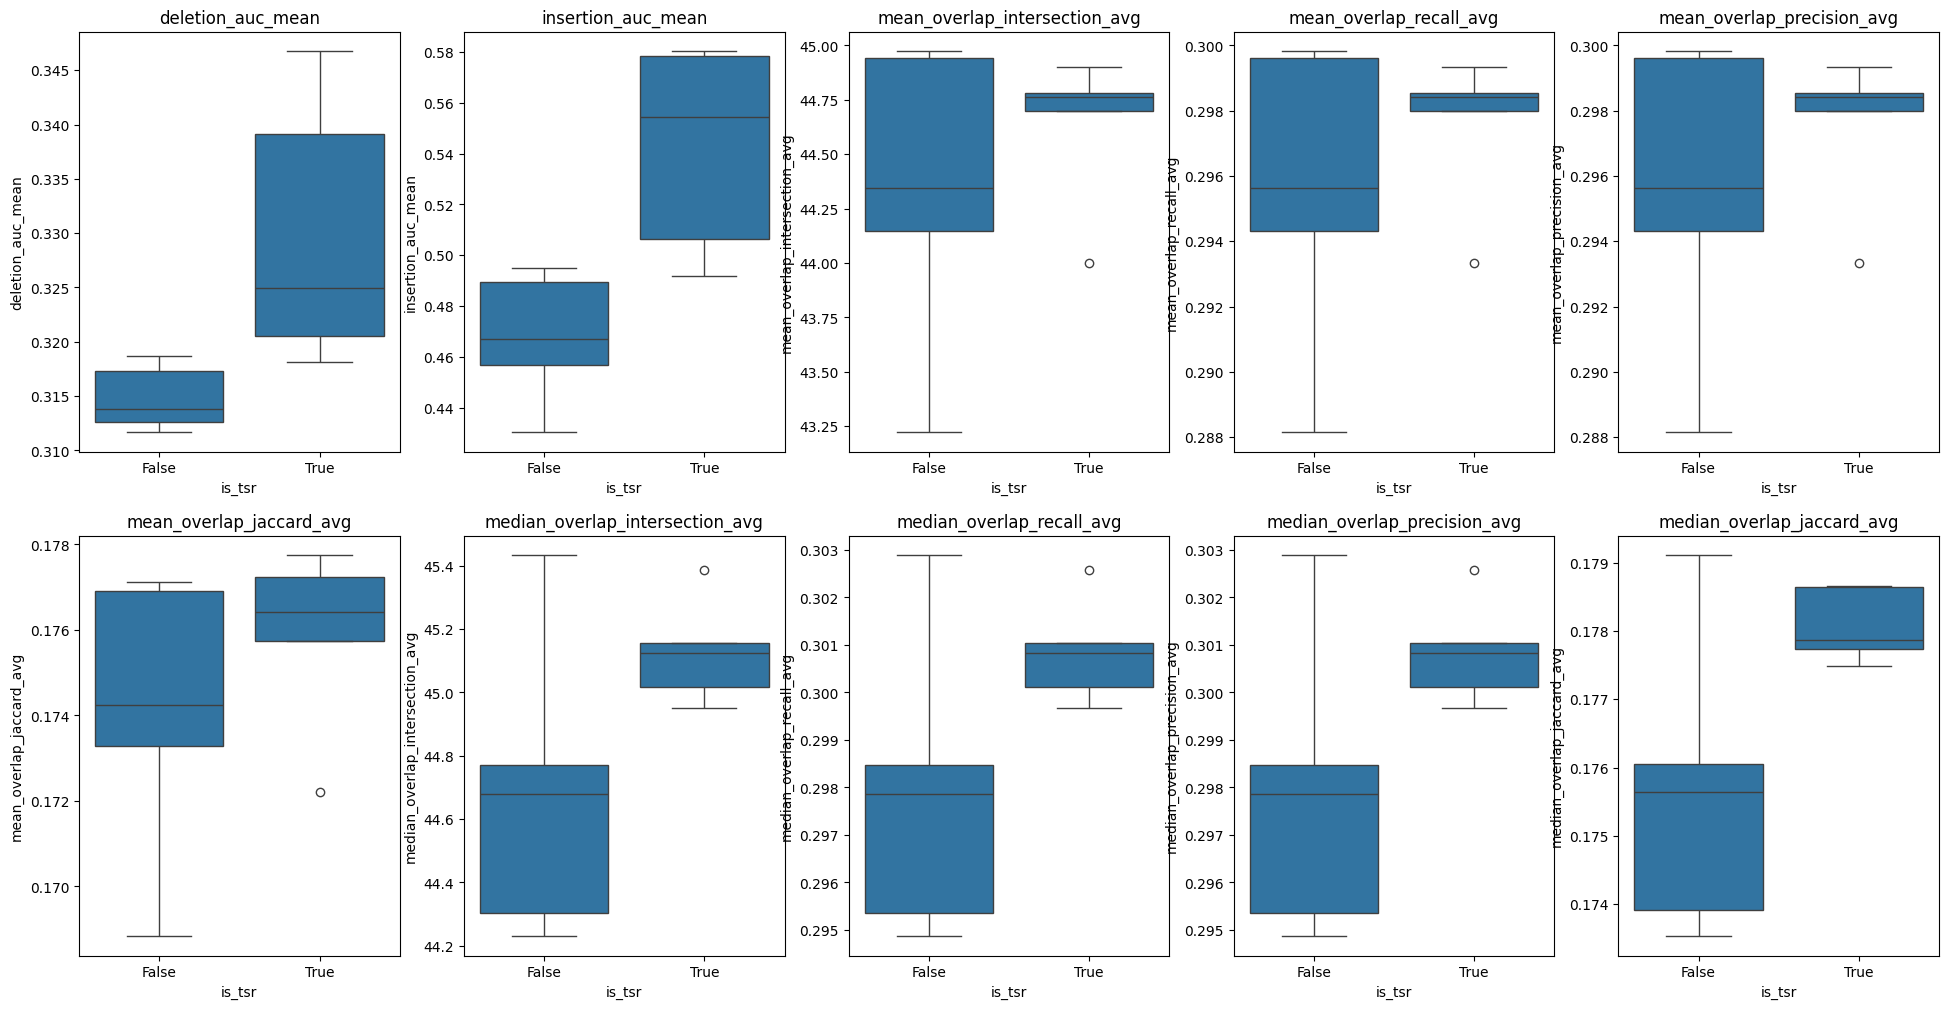

In [39]:
fig, ax = plt.subplots(2, 5, figsize=(24, 12))
axes = ax.flatten()

for axs, metric in zip(axes, metrics):

    sns.boxplot(data=results_df_without_baseline, y=metric, x='is_tsr', ax=axs) # метрики посмотрим без бейзлайнов
    axs.set_title(metric)

Опустив на данный момент семантику метрик, можно сказать, что различия в метриках по группам наблюдаются. Однако, детализируя внимание на y-axis, данные значения не являются сильными (посмотрим в парном сравнении). Метрики по TSR-картам всегда выше, но лишь чуть-чуть. 

Наиболее сильная амплитуда по deletion/insertion. Так как Deletion AUC по определению должна стремится к 0, то можно сказать, что TSR несколько ухудшает объяснения (хоть и значимо повышает instertion AUC). Такде по этим метрикам у TSR широкий разброс и здесь, для большей точности важен анализ на бОльшем количестве данных. 


Для остальным метрик TSR дает устойчивый рост, согласованный с целевым значением метрик. 

Посмотрим парный сетап. 

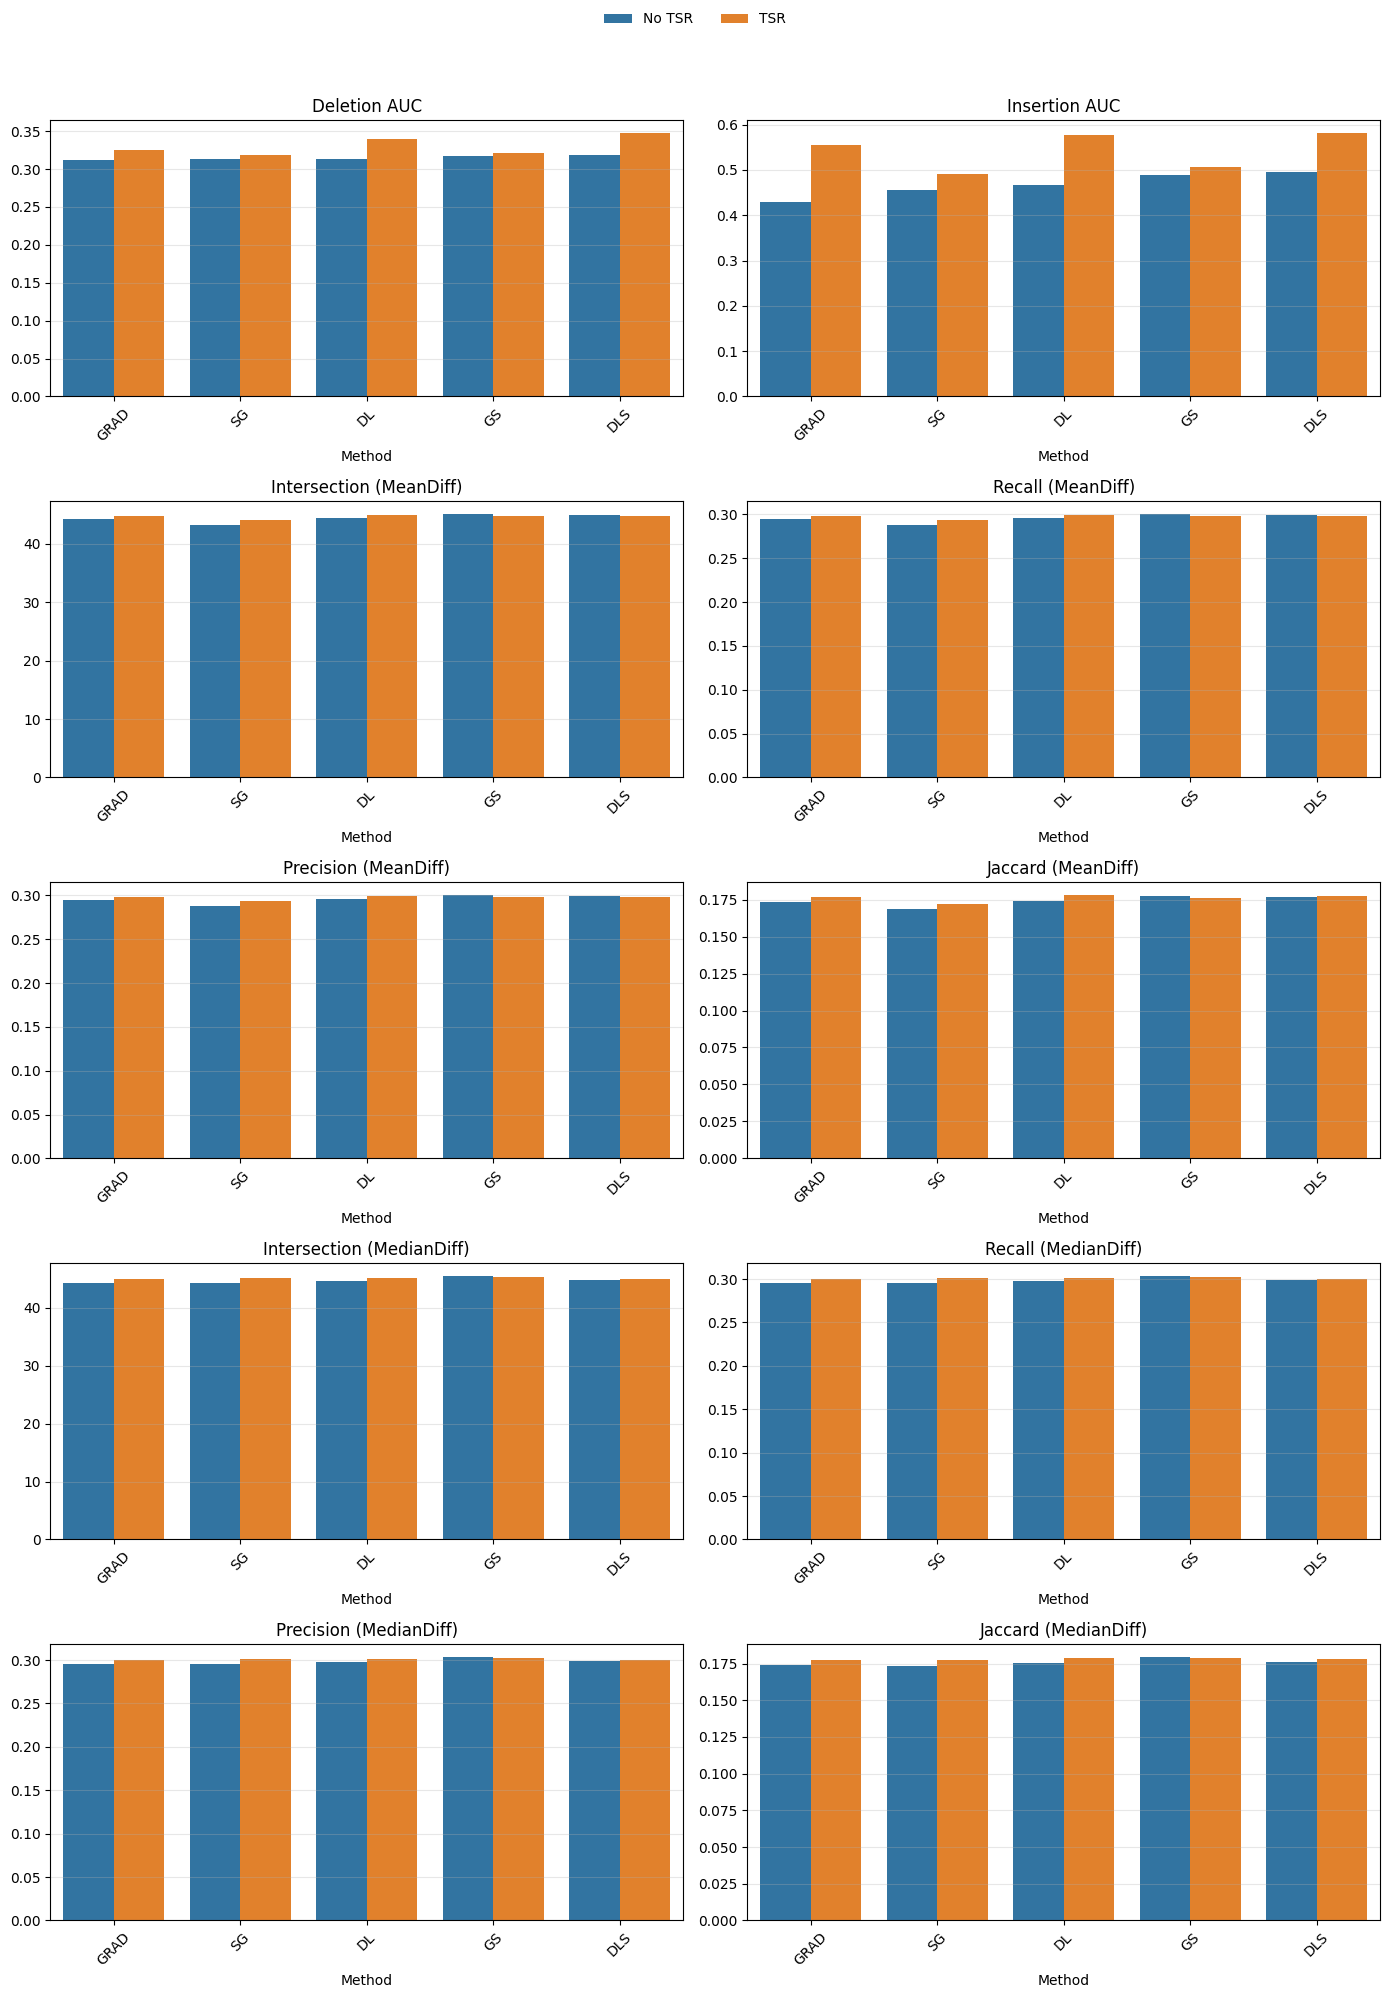

In [42]:
pair_df = results_df_without_baseline.copy()

pair_df["base_method"] = pair_df["method"].str.replace(r"\+TSR$", "", regex=True)
pair_df["tsr_label"] = np.where(pair_df["method"].str.contains(r"\+TSR$", regex=True), "TSR", "No TSR")

pair_df = pair_df[pair_df["base_method"].isin(["GRAD", "IG", "GS", "DL", "DLS", "SG", "FA", "FO"])].copy()

pair_rows = []


base_methods = ["GRAD", "IG", "GS", "DL", "DLS", "SG", "FA", "FO"]

metrics = [
    "deletion_auc_mean",
    "insertion_auc_mean",
    "mean_overlap_intersection_avg",
    "mean_overlap_recall_avg",
    "mean_overlap_precision_avg",
    "mean_overlap_jaccard_avg",
    "median_overlap_intersection_avg",
    "median_overlap_recall_avg",
    "median_overlap_precision_avg",
    "median_overlap_jaccard_avg",
]

titles = {
    "deletion_auc_mean": "Deletion AUC",
    "insertion_auc_mean": "Insertion AUC",
    "mean_overlap_intersection_avg": "Intersection (MeanDiff)",
    "mean_overlap_recall_avg": "Recall (MeanDiff)",
    "mean_overlap_precision_avg": "Precision (MeanDiff)",
    "mean_overlap_jaccard_avg": "Jaccard (MeanDiff)",
    "median_overlap_intersection_avg": "Intersection (MedianDiff)",
    "median_overlap_recall_avg": "Recall (MedianDiff)",
    "median_overlap_precision_avg": "Precision (MedianDiff)",
    "median_overlap_jaccard_avg": "Jaccard (MedianDiff)",
}

n_cols = 2
n_rows = int(np.ceil(len(metrics) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):

    sns.barplot(
        data=pair_df,
        x="base_method",
        y=metric,
        hue="tsr_label",
        ax=ax
    )

    ax.set_title(titles[metric])
    ax.set_xlabel("Method")
    ax.set_ylabel("")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

# убрать лишние оси если есть
for i in range(len(metrics), len(axes)):
    fig.delaxes(axes[i])

# общая легенда
handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
  

Как было описано выше, все метрики, кроме интегральных, различны на уровне малых значений. Данный факт не дает сказать, что TSR однозначно улучшает ситуацию от наивного baseline (примем важными в среднем/медианно отличные признаки). Говоря о baseline, посмотрим методы в сравнении с ним. 

Тут сосредоточимся на deletion и insertion метриках, так как для остальных референсые множества совпадают точб в точь. 

In [47]:
display(results_df[['method', 'deletion_auc_mean', 'insertion_auc_mean']].sort_values(by='deletion_auc_mean').head(3))
display(results_df[['method', 'deletion_auc_mean', 'insertion_auc_mean']].sort_values(by='insertion_auc_mean').tail(3))

,method,deletion_auc_mean,insertion_auc_mean
0,MeanDiff,0.306399,0.357789
1,GRAD,0.311654,0.430295
2,SG,0.312615,0.456714


,method,deletion_auc_mean,insertion_auc_mean
9,GRAD+TSR,0.324951,0.554221
10,DL+TSR,0.339169,0.578186
11,DLS+TSR,0.346795,0.580447


1. Deletion (lower better) лучшая у метода MeanDiff, далее идут классические градиетные методы saliency map и smooth grad.
2. Insertion (high better) принимает лучшие значения у методов с TSR.

## **Обобщение**

В проведенном эксперименте мы протестировали TSR по 2м пунктам:
1. Как конкурента обычнам картам в двух сетапах метрик;
2. Как конкурента с эвристическим методом (`MeanDiff` и `MedianDiff`)

На данном датасете мы видим, что применение **Temporal Saliency Rescaling (TSR)** приводит к неоднозначному влиянию на различные группы метрик. В частности, для большинства методов наблюдается увеличение значения **Insertion AUC**, что указывает на более быстрое восстановление уверенности модели при последовательном добавлении наиболее важных временных точек. Это свидетельствует о том, что после применения TSR карта важности становится более концентрированной.

В то же время, для метрики **Deletion AUC** наблюдается противоположная тенденция: значения чаще увеличиваются, что означает более медленное снижение уверенности модели при удалении наиболее важных точек. То есть , TSR делает карту более устойчивой к локальному удалению признаков, но одновременно усиливает эффект их постепенного добавления.

Анализ метрик совпадения с референсными множествами значимых временных точек (`MeanDiff` и `MedianDiff`) показывает, что применение TSR практически не изменяет структуру пересечений. Значения **Intersection**, **Recall**, **Precision** и **Jaccard** для большинства методов остаются на близком уровне по сравнению с исходными картами важности. На данном датасете. возможно. TSR в основном перераспределяет веса внутри карты важности, но не радикально меняя набор временных точек, попадающих в top-150 наиболее значимых индексов. То есть , метод выполняет локальное усиление уже выделенных областей, а не выявляет принципиально новые участки сигнала.

Интересно отметить, что глобальные baseline-подходы (`MeanDiff` и `MedianDiff`), основанные на статистических различиях между группами корректных и ошибочных классификаций, демонстрируют значительно более высокое совпадение с референсными наборами значимых точек, что ожидаемо, поскольку они непосредственно используются для их определения.Это показывает, что baseline XAI методы также важны, как и baseline ML алгоритмы. 



## **Ограничения**

1. Авторы прекрасно понимают, что результаты на одном датасете нельзя экстраполировать. Однако в нашем случае мы нашли *хотя бы один датасет, где tSR не надет универсальных преимуществ*, а значит метод не является "серебрянной пулей", хоть и может быть эффективным. 
2. Авторы также понимают, что нужно добавлять абляцию шагов, но в проекте мы проверяем живость в целом гипотезы. 

## **Спасибо!**